# 🎨 An Implementation of AdaIN Style Transfer

**Deep Learning Course** — supervised by Prof. N. Dif
B. Abdel-ouakil · M. Safouane Mohammed · A. Ines · B. Mohammed Amdjed

Arbitrary style transfer in real time with **Adaptive Instance Normalization** (Huang & Belongie, ICCV 2017).
A frozen VGG-19 encoder, a parameter-free AdaIN layer and a trained decoder, trained from scratch on **MS-COCO 2017** (content)
and **WikiArt** (style) across several Kaggle sessions, with checkpoints persisted to the Hugging Face Hub.

| Config | Batch | Iters | LR | LR decay | GPUs | Est. time | Note |
|---|---|---|---|---|---|---|---|
| **`DEMO`** | 16 | 3,000 | 2e-4 | 1e-4 | 2× T4 | ~15–25 min | Quick run — recognisable but rough stylisation |
| **`FAST`** | 16 | 8,000 | 2e-4 | 1e-4 | 2× T4 | ~55 min | **Default** — reduced budget, subset of the data, mixed precision |

### 🛠 Setup before running
1. **Settings → Accelerator → GPU T4 x2.**
2. **Settings → Internet → On** (VGG-19 ImageNet weights + Hugging Face Hub).
3. **Add Input** (right sidebar → *+ Add Input*): an **MS-COCO 2017** dataset with a `train2017/` folder (e.g. `awsaf49/coco-2017-dataset`)
   and a **WikiArt** dataset (e.g. `steubk/wikiart`). Both are found automatically.
4. *(Recommended)* **Add-ons → Secrets → add `HF_TOKEN`** (a Hugging Face token with *write* access) and attach it to this notebook.
   Checkpoints are then uploaded to a private model repo and the next session resumes from the newest one automatically.
5. **Train with "Save Version → Save & Run All (Commit)"**, not in the interactive editor. An interactive session is shut down when
   the browser tab is closed or idle, which kills the kernel mid-training. A committed run keeps going in the background for up to 12 h,
   and everything in `/kaggle/working` is saved as the version's output.
6. To continue in a later session: either use `HF_TOKEN` (automatic), or **+ Add Input → Your Work → this notebook's output** —
   the resume cell also looks for checkpoints in `/kaggle/input`.

---
## 1 · Environment setup

**Goal:** prepare a reproducible, GPU-ready environment before anything else runs.

What this cell does:
- Sets `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` to reduce CUDA memory fragmentation. It only takes effect if it is set
  **before** PyTorch initialises CUDA, so it is the very first thing executed (restart the kernel if you change it).
- Disables NCCL peer-to-peer / InfiniBand: Kaggle's two T4s have no working GPU-to-GPU link and P2P can hang multi-GPU code.
- Imports the libraries, relaxes PIL's limits (some WikiArt paintings are huge or slightly truncated), fixes the random seeds,
  creates the output folders under `/kaggle/working/` and prints the detected GPUs.

In [1]:
# ============================================================================
# 1 — Environment setup
# ============================================================================
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")   # before torch touches CUDA
os.environ.setdefault("NCCL_P2P_DISABLE", "1")   # Kaggle's 2× T4 have no working GPU-to-GPU link; P2P can hang NCCL
os.environ.setdefault("NCCL_IB_DISABLE", "1")

import re, json, time, math, glob, random, shutil, subprocess, warnings, itertools, faulthandler
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import models
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, Sampler
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
try:
    import psutil
except ImportError:
    psutil = None

Image.MAX_IMAGE_PIXELS = None            # some WikiArt paintings exceed PIL's decompression-bomb limit
ImageFile.LOAD_TRUNCATED_IMAGES = True   # tolerate the odd truncated JPEG

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

WORK = Path("/kaggle/working")
INPUT = Path("/kaggle/input")
CKPT_DIR = WORK / "checkpoints"
FIG_DIR = WORK / "figures"
PREVIEW_DIR = WORK / "previews"
VIDEO_DIR = WORK / "video"
for d in (CKPT_DIR, FIG_DIR, PREVIEW_DIR, VIDEO_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
torch.backends.cudnn.benchmark = True    # fixed 256×256 crops → let cuDNN pick the fastest kernels

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Device  : {DEVICE} | GPUs: {N_GPUS}")
for i in range(N_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} ({p.total_memory / 1e9:.1f} GB)")
print(f"PYTORCH_CUDA_ALLOC_CONF = {os.environ['PYTORCH_CUDA_ALLOC_CONF']}")

PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128
Device  : cuda | GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)
PYTORCH_CUDA_ALLOC_CONF = expandable_segments:True


---
## 2 · Configuration

**Goal:** gather every hyper-parameter in one place.

Pick a preset with `CONFIG_NAME`. Both presets train on a fixed random **subset** of the data (20k COCO images, 10k WikiArt
paintings) with fp16 mixed precision, so a full run fits in about an hour on a single T4. Each configuration gets its own run name
(`adain_<config>_c20k_s10k`), so its checkpoints never mix with another configuration's.

| Hyper-parameter | Value | Role |
|---|---|---|
| `STYLE_WEIGHT` (λs) | 10 | Balance between style and content loss, as in the paper |
| `LOAD_SIZE` / `CROP_SIZE` | 512 / 256 | Shorter side resized to 512 px, then a random 256×256 crop |
| `CKPT_INTERVAL` | 1,000 | Iterations between checkpoints and preview images |
| `SESSION_BUDGET_H` | 11.5 h | Stop cleanly before Kaggle's 12-hour limit |
| `N_HELDOUT_STYLES` | 100 | WikiArt paintings never used for training |

The learning rate follows the original AdaIN inverse-time schedule, $\text{lr}_t = \text{lr}_0 / (1 + \text{decay}\cdot t)$.
For `FAST` it goes from $2\times10^{-4}$ down to $\text{lr}_0/1.8 \approx 1.1\times10^{-4}$ at iteration 8,000.

In [2]:
# ============================================================================
# 2 — Configuration
# ============================================================================
CONFIGS = {
    "DEMO": dict(batch_size=16, num_iterations=3_000, lr=2e-4, lr_decay=1e-4),   # ~15–25 min on a T4
    "FAST": dict(batch_size=16, num_iterations=8_000, lr=2e-4, lr_decay=1e-4),   # ~55 min on a T4
}
CONFIG_NAME = "FAST"

cfg = CONFIGS[CONFIG_NAME]
BATCH_SIZE     = cfg["batch_size"]
NUM_ITERATIONS = cfg["num_iterations"]
LR             = cfg["lr"]
LR_DECAY       = cfg["lr_decay"]

# Train on a random subset of the datasets (None = use every image)
N_CONTENT_IMAGES = 20_000    # of ~118k COCO train2017 images
N_STYLE_IMAGES   = 10_000    # of ~81k WikiArt paintings

CONTENT_WEIGHT = 1.0
STYLE_WEIGHT   = 10.0        # λs, as in the original paper
LOAD_SIZE      = 512         # shorter side is resized to 512 …
CROP_SIZE      = 256         # … then a random 256×256 crop is taken

LOG_INTERVAL     = 100       # iterations between loss-history entries
CKPT_INTERVAL    = 1_000     # iterations between checkpoints (local + Hugging Face)
KEEP_LOCAL_CKPTS = 2
SESSION_BUDGET_H = 11.5      # stop cleanly (and checkpoint) before Kaggle's 12 h limit
USE_AMP          = True      # fp16 autocast: ~1.5–2× faster on T4
USE_DATAPARALLEL = False     # 2-GPU training with DataParallel; one T4 is enough here and avoids NCCL hangs
NUM_WORKERS      = 2         # per loader (content + style) → 4 workers on Kaggle's 4 CPUs
PREFETCH         = 2         # batches each worker keeps ready (higher = more host RAM)
MAX_DECODE_PIXELS = 40_000_000   # skip any image that would still decode larger than this (guards host RAM)
N_HELDOUT_STYLES = 100       # WikiArt paintings kept out of training, used to show unseen styles

RUN_NAME   = f"adain_{CONFIG_NAME.lower()}"
if N_CONTENT_IMAGES or N_STYLE_IMAGES:          # a different subset must never resume another subset's checkpoints
    RUN_NAME += f"_c{(N_CONTENT_IMAGES or 0) // 1000}k_s{(N_STYLE_IMAGES or 0) // 1000}k"
HF_REPO_ID = None            # e.g. "your-username/adain-style-transfer"; None → <your HF username>/adain-style-transfer

print(f"Config {CONFIG_NAME}: batch={BATCH_SIZE}, iterations={NUM_ITERATIONS:,}, lr={LR:g}, lr_decay={LR_DECAY:g}")
print(f"  final lr = {LR / (1 + LR_DECAY * NUM_ITERATIONS):.2e}  |  λs = {STYLE_WEIGHT:g}  |  AMP = {USE_AMP}  |  run = {RUN_NAME}")
print(f"  data: {N_CONTENT_IMAGES or 'all'} COCO images, {N_STYLE_IMAGES or 'all'} WikiArt paintings")

Config FAST: batch=16, iterations=8,000, lr=0.0002, lr_decay=0.0001
  final lr = 1.11e-04  |  λs = 10  |  AMP = True  |  run = adain_fast_c20k_s10k
  data: 20000 COCO images, 10000 WikiArt paintings


---
## 3 · Datasets

**Goal:** locate the two datasets and build the image lists used for training and for evaluation.

- **Content:** MS-COCO 2017 `train2017` (≈118k photos). **Style:** WikiArt (≈81k paintings).
  Both are mounted by Kaggle under `/kaggle/input`; nothing is downloaded. The cell finds them by shape (a `train2017/` folder,
  a folder whose name contains `wikiart`), so any mirror works — or set `CONTENT_DIR` / `STYLE_DIR` by hand.
- Listing ~200k files takes several minutes, so the lists are cached in `file_lists.json` and reused when the cell is re-run.
- File lists are **sorted**, so the same index always points to the same image in every session (required for exact resumption).
- **100 WikiArt paintings are held out** so that the results sections show *styles the decoder has never seen*;
  COCO `val2017` supplies *content images it has never seen*.
- Finally, a fixed random subset of 20,000 COCO images and 10,000 paintings is drawn for training.

In [3]:
# ============================================================================
# 3 — Dataset discovery
# ============================================================================
CONTENT_DIR = None    # override, e.g. "/kaggle/input/coco-2017-dataset/coco2017/train2017"
STYLE_DIR   = None    # override, e.g. "/kaggle/input/wikiart"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def discover_inputs(max_depth=6):
    """One pruned walk of /kaggle/input: COCO train2017 / val2017 folders and WikiArt roots."""
    found = {"train2017": [], "val2017": [], "wikiart": []}
    for root, dirs, _ in os.walk(INPUT):
        if len(Path(root).relative_to(INPUT).parts) >= max_depth:
            dirs[:] = []; continue
        keep = []
        for d in dirs:
            if d in ("train2017", "val2017"):
                found[d].append(Path(root) / d)
            elif "wikiart" in d.lower():
                found["wikiart"].append(Path(root) / d)
            else:
                keep.append(d)
        dirs[:] = keep                       # never descend into the big image folders
    return found

def list_images(root):
    out = []
    for r, _, files in os.walk(root):
        out += [os.path.join(r, f) for f in files if os.path.splitext(f)[1].lower() in IMG_EXTS]
    return sorted(out)

found = discover_inputs()
content_dir = Path(CONTENT_DIR) if CONTENT_DIR else next(iter(found["train2017"]), None)
style_dir   = Path(STYLE_DIR) if STYLE_DIR else min(found["wikiart"], key=lambda p: len(p.parts), default=None)
val_dir     = next(iter(found["val2017"]), None)

assert content_dir is not None, "MS-COCO 2017 not found — add it via + Add Input (needs a train2017/ folder) or set CONTENT_DIR."
assert style_dir is not None,   "WikiArt not found — add it via + Add Input or set STYLE_DIR."

t0 = time.time()
LIST_CACHE = WORK / "file_lists.json"       # listing ~200k files takes minutes; re-runs in a session reuse it
key = [str(content_dir), str(style_dir), str(val_dir)]
cache = json.loads(LIST_CACHE.read_text()) if LIST_CACHE.exists() else {}
if cache.get("key") == key:
    content_paths, style_all, val_paths = cache["content"], cache["style"], cache["val"]
else:
    content_paths = list_images(content_dir)
    style_all     = list_images(style_dir)
    val_paths     = list_images(val_dir) if val_dir else []
    LIST_CACHE.write_text(json.dumps({"key": key, "content": content_paths, "style": style_all, "val": val_paths}))
assert content_paths and style_all, "found the dataset folders but no images inside them"

# Hold out a fixed set of WikiArt paintings (never trained on) for the results section
N_HELDOUT_STYLES = globals().get("N_HELDOUT_STYLES", 100)   # set in section 2; default if that cell was skipped
N_CONTENT_IMAGES = globals().get("N_CONTENT_IMAGES", None)
N_STYLE_IMAGES   = globals().get("N_STYLE_IMAGES", None)
SEED = globals().get("SEED", 42)
rng = np.random.default_rng(SEED)
heldout_mask = np.zeros(len(style_all), dtype=bool)
heldout_mask[rng.permutation(len(style_all))[:N_HELDOUT_STYLES]] = True
heldout_styles = [p for p, h in zip(style_all, heldout_mask) if h]
style_paths    = [p for p, h in zip(style_all, heldout_mask) if not h]
display_content = val_paths if val_paths else content_paths[-500:]

# Random subset for training (fixed seed → the same subset in every session)
n_content_total, n_style_total = len(content_paths), len(style_paths)
sub_rng = np.random.default_rng(SEED + 3)
if N_CONTENT_IMAGES and len(content_paths) > N_CONTENT_IMAGES:
    content_paths = sorted(sub_rng.choice(content_paths, N_CONTENT_IMAGES, replace=False).tolist())
if N_STYLE_IMAGES and len(style_paths) > N_STYLE_IMAGES:
    style_paths = sorted(sub_rng.choice(style_paths, N_STYLE_IMAGES, replace=False).tolist())

print(f"Content (COCO train2017): {len(content_paths):>7,} of {n_content_total:,}  ← {content_dir}")
print(f"Style   (WikiArt, train): {len(style_paths):>7,} of {n_style_total:,}  ← {style_dir}")
print(f"Held-out styles          : {len(heldout_styles):>7,}")
print(f"Display content          : {len(display_content):>7,}  ({'COCO val2017' if val_paths else 'tail of train2017'})")
print(f"Listed in {time.time() - t0:.1f}s")

Content (COCO train2017):  20,000 of 118,287  ← /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
Style   (WikiArt, train):  10,000 of 81,344  ← /kaggle/input/datasets/steubk/wikiart
Held-out styles          :     100
Display content          :   5,000  (COCO val2017)
Listed in 843.7s


---
## 4 · Data pipeline & reproducible sampling

**Goal:** feed the GPU fast enough, and make training resumable at the exact sample where it stopped.

**Pre-processing.** Each image is resized so its shorter side is 512 px, then a random 256×256 crop is taken (as in the paper).
JPEGs are opened with PIL's `draft` mode, which lets the JPEG decoder downscale large paintings directly — a big speed-up on WikiArt.
Unreadable or absurdly large files are skipped deterministically.

**Reproducible data loading.** A `DataLoader` with `shuffle=True` draws a new order from a per-epoch generator that cannot be restored
mid-epoch. Instead, a flat sequence of `NUM_ITERATIONS × BATCH_SIZE` indices is pre-generated at the start of every session with
`np.random.default_rng` and a fixed seed (concatenated permutations, so every image is seen once per epoch). Resuming from iteration
*k* is just slicing the sequence from `k × BATCH_SIZE` — no cost to skip already-seen batches.

The cell ends by showing the first content and style crops of the sequence.

Pre-generated 128,000 content + 128,000 style indices (≈6.4 COCO epochs, ≈12.8 WikiArt epochs)


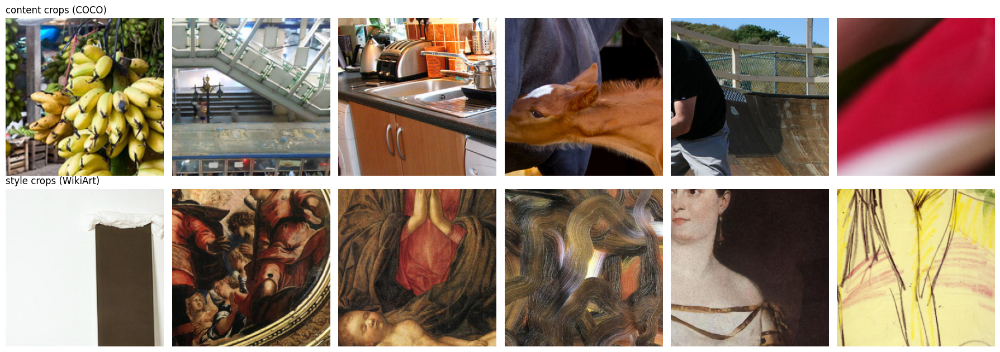

In [4]:
# ============================================================================
# 4 — Data pipeline & reproducible sampling
# ============================================================================
def load_pil(path, size=None):
    img = Image.open(path)
    if size:
        img.draft("RGB", (size, size))      # JPEG: decode at reduced scale, still ≥ size on both sides
    if img.size[0] * img.size[1] > MAX_DECODE_PIXELS:
        # a huge non-JPEG painting would need several GB of RAM per worker; the dataset skips to the next file
        raise ValueError(f"{os.path.basename(path)}: {img.size} is too large to decode safely")
    return img.convert("RGB")

class ImageListDataset(Dataset):
    def __init__(self, paths, load_size=LOAD_SIZE, crop_size=CROP_SIZE):
        self.paths = paths
        self.load_size = load_size
        self.tf = T.Compose([T.Resize(load_size), T.RandomCrop(crop_size), T.ToTensor()])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        for k in range(10):                 # skip unreadable files deterministically
            try:
                return self.tf(load_pil(self.paths[(i + k) % len(self.paths)], self.load_size))
            except Exception:
                continue
        raise RuntimeError(f"10 unreadable images in a row starting at {self.paths[i]}")

def make_index_sequence(n_items, total, seed):
    """Flat, pre-generated sequence of `total` indices built from concatenated random permutations."""
    rng = np.random.default_rng(seed)
    reps = math.ceil(total / n_items)
    return np.concatenate([rng.permutation(n_items) for _ in range(reps)])[:total]

class IndexSequenceSampler(Sampler):
    def __init__(self, indices): self.indices = indices
    def __iter__(self): return iter(self.indices.tolist())
    def __len__(self): return len(self.indices)

def make_loader(dataset, indices, start_iter):
    """DataLoader that yields exactly the batches from iteration `start_iter` onward."""
    sampler = IndexSequenceSampler(indices[start_iter * BATCH_SIZE:])
    return DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler, drop_last=True,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      persistent_workers=NUM_WORKERS > 0,
                      prefetch_factor=PREFETCH if NUM_WORKERS > 0 else None,
                      timeout=600 if NUM_WORKERS > 0 else 0)   # a stuck worker raises an error instead of hanging forever

content_ds = ImageListDataset(content_paths)
style_ds   = ImageListDataset(style_paths)
TOTAL_SAMPLES = NUM_ITERATIONS * BATCH_SIZE
content_idx = make_index_sequence(len(content_ds), TOTAL_SAMPLES, SEED)
style_idx   = make_index_sequence(len(style_ds),   TOTAL_SAMPLES, SEED + 1)
print(f"Pre-generated {TOTAL_SAMPLES:,} content + {TOTAL_SAMPLES:,} style indices "
      f"(≈{TOTAL_SAMPLES / len(content_ds):.1f} COCO epochs, ≈{TOTAL_SAMPLES / len(style_ds):.1f} WikiArt epochs)")

# Preview: the first training crops of the sequence
fig, axes = plt.subplots(2, 6, figsize=(18, 6.4))
for j in range(6):
    axes[0, j].imshow(content_ds[int(content_idx[j])].permute(1, 2, 0)); axes[0, j].axis("off")
    axes[1, j].imshow(style_ds[int(style_idx[j])].permute(1, 2, 0));     axes[1, j].axis("off")
axes[0, 0].set_title("content crops (COCO)", loc="left")
axes[1, 0].set_title("style crops (WikiArt)", loc="left")
plt.tight_layout(); plt.show()

---
## 5 · Model: encoder, AdaIN, decoder

**Goal:** define the network, the losses and the inference helpers, then check them on random tensors.

**AdaIN.** For content features $x$ and style features $y$ (channel-wise mean $\mu$ and std $\sigma$ over the spatial dimensions):

$$\text{AdaIN}(x, y) = \sigma(y)\left(\frac{x - \mu(x)}{\sigma(x)}\right) + \mu(y)$$

It has no learnable parameters. At inference, $t_\alpha = \alpha\,\text{AdaIN}(x, y) + (1-\alpha)\,x$ controls the strength of the style.

| Component | Details | Parameters |
|---|---|---|
| **Encoder** | VGG-19 pretrained on ImageNet, up to `relu4_1`, **frozen**; returns `relu1_1, relu2_1, relu3_1, relu4_1`. ImageNet normalisation is built in, so the decoder works directly in $[0,1]$ pixel space | 3.5 M (frozen) |
| **AdaIN** | Statistics transfer between content and style features | 0 |
| **Decoder** | Mirror of the encoder: nearest-neighbour upsampling instead of pooling, reflection padding. **The only trained component** | 3.5 M (trained) |

**Losses** (both in VGG feature space, $g$ = decoder, $f$ = encoder, $\phi_i$ = encoder layer $i$, $t$ = AdaIN output, $s$ = style image):

$$\mathcal{L}_c = \lVert f(g(t)) - t \rVert_2^2 \qquad
\mathcal{L}_s = \sum_{i=1}^{4} \lVert \mu(\phi_i(g(t))) - \mu(\phi_i(s)) \rVert_2 + \lVert \sigma(\phi_i(g(t))) - \sigma(\phi_i(s)) \rVert_2$$

$$\mathcal{L} = \mathcal{L}_c + \lambda_s \mathcal{L}_s, \qquad \lambda_s = 10$$

(implemented as mean-squared errors, as in the reference implementation). The content target is the AdaIN output $t$ rather than
the content image's features, which pushes the decoder to reproduce the *re-styled* features faithfully.

**Training module.** Encoder, AdaIN, decoder and losses live in one `AdaINNet` module. It can be wrapped in `torch.nn.DataParallel`
so each GPU encodes, decodes and scores its own share of the batch; the `FAST` and `DEMO` presets run on a single T4.

**Sanity checks** at the end of the cell: feature shapes at each VGG level, decoder output shape, AdaIN output statistics vs the
style statistics, initial losses and parameter counts.

In [5]:
# ============================================================================
# 5 — Model: AdaIN, VGG-19 encoder, decoder, training module, inference helpers
# ============================================================================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def calc_mean_std(feat, eps=1e-5):
    """Channel-wise mean / std over spatial dims, computed in fp32. Returns (N,C,1,1) tensors."""
    n, c = feat.shape[:2]
    f = feat.float().reshape(n, c, -1)
    mean = f.mean(dim=2).view(n, c, 1, 1)
    std = (f.var(dim=2) + eps).sqrt().view(n, c, 1, 1)
    return mean, std

def adain_with_stats(content_feat, s_mean, s_std):
    c_mean, c_std = calc_mean_std(content_feat)
    normalized = (content_feat.float() - c_mean) / c_std
    return (normalized * s_std + s_mean).to(content_feat.dtype)

def adain(content_feat, style_feat):
    s_mean, s_std = calc_mean_std(style_feat)
    return adain_with_stats(content_feat, s_mean, s_std)

class VGGEncoder(nn.Module):
    """VGG-19 (ImageNet) up to relu4_1, frozen. forward → (relu1_1, relu2_1, relu3_1, relu4_1)."""
    def __init__(self):
        super().__init__()
        feats = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features[:21]
        for m in feats.modules():
            if isinstance(m, nn.ReLU):
                m.inplace = False
        assert isinstance(feats[20], nn.ReLU) and feats[19].out_channels == 512, "unexpected VGG-19 layout"
        self.slice1 = feats[:2]      # conv1_1 → relu1_1
        self.slice2 = feats[2:7]     # … → relu2_1
        self.slice3 = feats[7:12]    # … → relu3_1
        self.slice4 = feats[12:21]   # … → relu4_1
        self.register_buffer("mean", torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(IMAGENET_STD).view(1, 3, 1, 1))
        self.requires_grad_(False)
        self.eval()

    def forward(self, x):
        h1 = self.slice1((x - self.mean) / self.std)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return h1, h2, h3, h4

    def encode(self, x):
        return self.forward(x)[-1]

def build_decoder():
    """Mirror of VGG-19 up to relu4_1: nearest-neighbour upsampling, reflection padding."""
    pad = lambda: nn.ReflectionPad2d((1, 1, 1, 1))
    return nn.Sequential(
        pad(), nn.Conv2d(512, 256, 3), nn.ReLU(),
        nn.Upsample(scale_factor=2, mode="nearest"),
        pad(), nn.Conv2d(256, 256, 3), nn.ReLU(),
        pad(), nn.Conv2d(256, 256, 3), nn.ReLU(),
        pad(), nn.Conv2d(256, 256, 3), nn.ReLU(),
        pad(), nn.Conv2d(256, 128, 3), nn.ReLU(),
        nn.Upsample(scale_factor=2, mode="nearest"),
        pad(), nn.Conv2d(128, 128, 3), nn.ReLU(),
        pad(), nn.Conv2d(128, 64, 3), nn.ReLU(),
        nn.Upsample(scale_factor=2, mode="nearest"),
        pad(), nn.Conv2d(64, 64, 3), nn.ReLU(),
        pad(), nn.Conv2d(64, 3, 3),
    )

class AdaINNet(nn.Module):
    """Encoder + AdaIN + decoder + losses. Wrapped in DataParallel, every GPU handles its own share of the batch."""
    def __init__(self, encoder, decoder, use_amp=False):
        super().__init__()
        self.encoder, self.decoder, self.use_amp = encoder, decoder, use_amp

    def forward(self, content, style, alpha: float = 1.0):
        # autocast is thread-local, so it must be entered inside forward for DataParallel replicas
        with torch.amp.autocast(device_type="cuda", enabled=self.use_amp and content.is_cuda):
            style_feats = self.encoder(style)
            content_feat = self.encoder.encode(content)
            t = adain(content_feat, style_feats[-1])
            t = alpha * t + (1 - alpha) * content_feat
            g_t = self.decoder(t)
            g_feats = self.encoder(g_t)
        loss_c = F.mse_loss(g_feats[-1].float(), t.float())
        loss_s = 0.0
        for g, s in zip(g_feats, style_feats):
            g_mean, g_std = calc_mean_std(g)
            s_mean, s_std = calc_mean_std(s)
            loss_s = loss_s + F.mse_loss(g_mean, s_mean) + F.mse_loss(g_std, s_std)
        return loss_c.unsqueeze(0), loss_s.unsqueeze(0)   # 1-element tensors gather cleanly across GPUs

encoder = VGGEncoder().to(DEVICE)
decoder = build_decoder().to(DEVICE)
net = AdaINNet(encoder, decoder, use_amp=USE_AMP).to(DEVICE)
USE_DATAPARALLEL = globals().get("USE_DATAPARALLEL", True)
net_dp = nn.DataParallel(net) if (N_GPUS > 1 and USE_DATAPARALLEL) else net

# ---- inference helpers (single GPU) ----
def load_image(path, size=512, square=False):
    """(3,H,W) tensor in [0,1]; shorter side = size; H and W cropped to multiples of 8 (the decoder upsamples ×8)."""
    img = TF.resize(load_pil(path, size), size)
    if square:
        img = TF.center_crop(img, size)
    w, h = img.size
    return TF.to_tensor(img.crop((0, 0, w - w % 8, h - h % 8)))

@torch.no_grad()
def stylize(content, style, alpha=1.0):
    """content: (3,H,W) or (B,3,H,W); style: (3,h,w) or (1,3,h,w); values in [0,1]. Returns the result on CPU."""
    single = content.dim() == 3
    c = (content.unsqueeze(0) if single else content).to(DEVICE)
    s = (style.unsqueeze(0) if style.dim() == 3 else style).to(DEVICE)
    cf = encoder.encode(c)
    t = adain(cf, encoder.encode(s))
    t = alpha * t + (1 - alpha) * cf
    out = decoder(t).clamp(0, 1).cpu()
    return out[0] if single else out

def show(ax, img, title=None):
    ax.imshow(img.permute(1, 2, 0).numpy() if torch.is_tensor(img) else img)
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10)

# ---- sanity checks ----
with torch.no_grad():
    _x = torch.rand(2, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)
    _y = torch.rand(2, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)
    _feats = encoder(_x)
    _t = adain(_feats[-1], encoder.encode(_y))
    _tm, _ts = calc_mean_std(_t); _sm, _ss = calc_mean_std(encoder.encode(_y))
    _lc, _ls = net_dp(_x, _y)
print("feature shapes :", [tuple(f.shape[1:]) for f in _feats])
print(f"decoder output : {tuple(decoder(_t).shape)}")
print(f"AdaIN stats    : |Δμ|={(_tm - _sm).abs().max():.1e}  |Δσ|={(_ts - _ss).abs().max():.1e}  (≈0 ✓)")
print(f"initial losses : Lc={_lc.mean():.3f}  Ls={_ls.mean():.3f}")
print(f"encoder params : {sum(p.numel() for p in encoder.parameters()) / 1e6:.2f} M (frozen)")
print(f"decoder params : {sum(p.numel() for p in decoder.parameters()) / 1e6:.2f} M (trained)")
print(f"DataParallel   : {'on, ' + str(N_GPUS) + ' GPUs' if net_dp is not net else 'off (single GPU)'}")
del _x, _y, _feats, _t, _tm, _ts, _sm, _ss, _lc, _ls

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 197MB/s]


feature shapes : [(64, 256, 256), (128, 128, 128), (256, 64, 64), (512, 32, 32)]
decoder output : (2, 3, 256, 256)
AdaIN stats    : |Δμ|=9.5e-07  |Δσ|=2.2e-01  (≈0 ✓)
initial losses : Lc=8.530  Ls=63.529
encoder params : 3.51 M (frozen)
decoder params : 3.51 M (trained)
DataParallel   : off (single GPU)


---
## 6 · Checkpoints & automatic resume (Hugging Face Hub)

**Goal:** never lose training progress when a Kaggle session ends.

Every `CKPT_INTERVAL` iterations the **decoder weights, optimizer state, AMP scaler state and full loss history** are saved
atomically to `/kaggle/working/checkpoints/<run>/`, and uploaded (in one commit) to a private Hugging Face model repo.

At start-up the cell looks for the **highest-numbered checkpoint** of this run in three places — the local folder, a previous
notebook version added as input, and the Hub — downloads it if needed and restores all state, including the loss history, so the
curves in section 8 cover the whole run. Without an `HF_TOKEN` secret everything still works, but checkpoints only live in
`/kaggle/working/` (kept if you *Save Version*).

In [6]:
# ============================================================================
# 6 — Checkpoint persistence (local + Hugging Face Hub) and automatic resume
# ============================================================================
from huggingface_hub import HfApi, hf_hub_download, CommitOperationAdd

def _get_hf_token():
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        return os.environ.get("HF_TOKEN")

HF_TOKEN = _get_hf_token()
hf_api = None
if HF_TOKEN:
    try:
        hf_api = HfApi(token=HF_TOKEN)
        if HF_REPO_ID is None:
            HF_REPO_ID = f"{hf_api.whoami()['name']}/adain-style-transfer"
        hf_api.create_repo(HF_REPO_ID, repo_type="model", private=True, exist_ok=True)
        print(f"✓ Hugging Face repo: https://huggingface.co/{HF_REPO_ID}")
    except Exception as e:
        print(f"⚠ Hugging Face unavailable ({type(e).__name__}: {e}) — checkpoints stay local")
        hf_api = None
else:
    print("ℹ No HF_TOKEN secret — checkpoints are saved to /kaggle/working only.")

RUN_DIR = CKPT_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT_RE = re.compile(r"ckpt_(\d{6})\.pt$")

optimizer = torch.optim.Adam(decoder.parameters(), lr=LR)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

def lr_at(it):
    return LR / (1.0 + LR_DECAY * it)

def run_config():
    return {"config": CONFIG_NAME, "batch_size": BATCH_SIZE, "num_iterations": NUM_ITERATIONS,
            "lr": LR, "lr_decay": LR_DECAY, "style_weight": STYLE_WEIGHT, "seed": SEED,
            "n_gpus": N_GPUS, "use_amp": USE_AMP}

def save_checkpoint(it, history):
    path = RUN_DIR / f"ckpt_{it:06d}.pt"
    state = {"iter": it, "decoder": decoder.state_dict(), "optimizer": optimizer.state_dict(),
             "scaler": scaler.state_dict(), "history": history, "config": run_config()}
    tmp = path.with_name(path.name + ".tmp")
    torch.save(state, tmp); os.replace(tmp, path)                 # atomic: never a half-written checkpoint
    torch.save(decoder.state_dict(), RUN_DIR / "decoder_latest.pth")
    (RUN_DIR / "history.json").write_text(json.dumps({"config": run_config(), "history": history}))
    files = [path, RUN_DIR / "decoder_latest.pth", RUN_DIR / "history.json"]
    if it >= NUM_ITERATIONS:
        shutil.copyfile(RUN_DIR / "decoder_latest.pth", RUN_DIR / "decoder_final.pth")
        files.append(RUN_DIR / "decoder_final.pth")
    for old in sorted(RUN_DIR.glob("ckpt_*.pt"))[:-KEEP_LOCAL_CKPTS]:
        old.unlink(missing_ok=True)
    msg = f"saved {path.name}"
    if hf_api is not None:
        try:
            hf_api.create_commit(
                repo_id=HF_REPO_ID, commit_message=f"{RUN_NAME}: iteration {it}",
                operations=[CommitOperationAdd(path_in_repo=f"{RUN_NAME}/{f.name}", path_or_fileobj=str(f))
                            for f in files])
            msg += " + uploaded to the Hub"
        except Exception as e:
            msg += f" (⚠ upload failed: {type(e).__name__}: {e})"
    tqdm.write(f"💾 {msg}")

def find_latest_checkpoint():
    """(iteration, 'local' | 'hub' | None, path-or-repo-filename) of the newest checkpoint for this run."""
    best = (0, None, None)
    for p in RUN_DIR.glob("ckpt_*.pt"):
        m = CKPT_RE.search(p.name)
        if m and int(m.group(1)) > best[0]:
            best = (int(m.group(1)), "local", p)
    # checkpoints from an earlier version's output added as input (+ Add Input → Your Work)
    for depth in range(4):
        for p in INPUT.glob("*/" * depth + f"checkpoints/{RUN_NAME}/ckpt_*.pt"):
            m = CKPT_RE.search(p.name)
            if m and int(m.group(1)) > best[0]:
                best = (int(m.group(1)), "input", p)
    if hf_api is not None:
        try:
            for f in hf_api.list_repo_files(HF_REPO_ID):
                m = CKPT_RE.search(f)
                if f.startswith(f"{RUN_NAME}/") and m and int(m.group(1)) > best[0]:
                    best = (int(m.group(1)), "hub", f)
        except Exception as e:
            print(f"⚠ could not list {HF_REPO_ID}: {e}")
    return best

RESUME = True
start_iter, history = 0, []
found_iter, where, ref = find_latest_checkpoint() if RESUME else (0, None, None)
if where is None:
    print("ℹ No checkpoint found — training starts from scratch.")
else:
    if where == "hub":
        print(f"⬇ downloading {ref} from {HF_REPO_ID} …")
        ref = Path(hf_hub_download(HF_REPO_ID, ref, local_dir=str(CKPT_DIR), token=HF_TOKEN))
    state = torch.load(ref, map_location=DEVICE, weights_only=False)   # our own file
    saved_cfg = state.get("config", {})
    if saved_cfg.get("batch_size", BATCH_SIZE) != BATCH_SIZE:
        raise ValueError(f"checkpoint used batch {saved_cfg['batch_size']}, this run uses {BATCH_SIZE} — "
                         "the index sequence would not line up. Pick the matching CONFIG_NAME.")
    decoder.load_state_dict(state["decoder"])
    optimizer.load_state_dict(state["optimizer"])
    if state.get("scaler"):
        scaler.load_state_dict(state["scaler"])
    start_iter, history = state["iter"], state.get("history", [])
    print(f"⤴ resumed from {ref.name} ({where}): iteration {start_iter:,}/{NUM_ITERATIONS:,}, "
          f"{len(history)} history points, next lr = {lr_at(start_iter):.2e}")

ℹ No HF_TOKEN secret — checkpoints are saved to /kaggle/working only.
ℹ No checkpoint found — training starts from scratch.


---
## 7 · Training

**Goal:** train the decoder.

- **Optimiser:** Adam on the decoder only, with the inverse-time learning-rate decay of section 2 and fp16 autocast + gradient scaling.
- **Pre-flight checks** (timestamped): one training step on random data (GPU path only), then starting the data workers and loading
  the first batch. If a run ever stops, the last line printed shows which part failed, and `/kaggle/working/faulthandler.log` holds
  Python's stack trace of the crash or hang.
- **Logging:** every `LOG_INTERVAL` iterations the averaged losses and learning rate are appended to the history; every 500 iterations
  a plain-text line with the losses, speed and RAM/GPU memory is printed (readable in the log of a committed run).
- **Checkpoints and previews:** every `CKPT_INTERVAL` iterations a checkpoint is written (and uploaded) and a
  *content | style | output* preview is saved to `/kaggle/working/previews/`.
- **Safe stop:** if the session approaches `SESSION_BUDGET_H` hours, the loop saves a checkpoint and stops cleanly — just **Run All**
  again in a new session. Once `NUM_ITERATIONS` is reached, re-running this cell does nothing.

In [7]:
# ============================================================================
# 7 — Training loop
# ============================================================================
preview_content = display_content[0]
preview_style = heldout_styles[0]

def save_preview(it):
    c = load_image(preview_content, CROP_SIZE, square=True)
    s = load_image(preview_style, CROP_SIZE, square=True)
    out = stylize(c, s)
    TF.to_pil_image(torch.cat([c, s, out], dim=2)).save(PREVIEW_DIR / f"{RUN_NAME}_{it:06d}.jpg", quality=92)

def mem_report():
    parts = []
    if psutil is not None:
        vm = psutil.virtual_memory()
        rss = psutil.Process().memory_info().rss
        for ch in psutil.Process().children(recursive=True):
            try: rss += ch.memory_info().rss
            except Exception: pass
        parts.append(f"RAM {vm.used / 1e9:.1f}/{vm.total / 1e9:.1f} GB (notebook+workers {rss / 1e9:.1f} GB)")
    for i in range(N_GPUS):
        parts.append(f"GPU{i} {torch.cuda.max_memory_allocated(i) / 1e9:.1f} GB peak")
    return " | ".join(parts)

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)

# If the kernel crashes or hangs, Python's stack traces are written here (and saved with the output)
FAULT_LOG = WORK / "faulthandler.log"
_fault_file = open(FAULT_LOG, "w")
faulthandler.enable(file=_fault_file, all_threads=True)
faulthandler.dump_traceback_later(900, repeat=True, file=_fault_file)   # every 15 min while running

if start_iter >= NUM_ITERATIONS:
    print(f"✓ {RUN_NAME} already trained for {NUM_ITERATIONS:,} iterations — skipping to the results.")
else:
    # ---- pre-flight 1/2: one step on random data — GPU only, no data loading ----
    log(f"pre-flight 1/2: one training step on random data ({'DataParallel, ' + str(N_GPUS) + ' GPUs' if net_dp is not net else 'single GPU'}) …")
    t0 = time.time()
    _c = torch.rand(BATCH_SIZE, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)
    _s = torch.rand(BATCH_SIZE, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)
    _lc, _ls = net_dp(_c, _s)
    scaler.scale(CONTENT_WEIGHT * _lc.mean() + STYLE_WEIGHT * _ls.mean()).backward()
    optimizer.zero_grad(set_to_none=True)        # discard: this step only checks the GPU path
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    del _c, _s, _lc, _ls
    log(f"✓ GPU step OK in {time.time() - t0:.1f}s | {mem_report()}")

    # ---- pre-flight 2/2: start the data workers and fetch the first batch ----
    log(f"pre-flight 2/2: starting {2 * NUM_WORKERS} data workers and loading the first batch …")
    t0 = time.time()
    content_loader = make_loader(content_ds, content_idx, start_iter)
    style_loader = make_loader(style_ds, style_idx, start_iter)
    content_iter, style_iter = iter(content_loader), iter(style_loader)
    first_batch = (next(content_iter), next(style_iter))
    log(f"✓ first batch loaded in {time.time() - t0:.1f}s | {mem_report()}")
    print(f"Training {RUN_NAME}: iterations {start_iter:,} → {NUM_ITERATIONS:,} "
          f"({len(content_loader):,} left this run, budget {SESSION_BUDGET_H} h)")

    print(f"before training: {mem_report()}", flush=True)
    net_dp.train()
    session_start = time.time()
    it = start_iter
    acc = {"loss": 0.0, "loss_c": 0.0, "loss_s": 0.0, "n": 0}
    pbar = tqdm(total=NUM_ITERATIONS, initial=start_iter, desc=RUN_NAME, dynamic_ncols=True)

    for content, style in itertools.chain([first_batch], zip(content_iter, style_iter)):
        lr = lr_at(it)
        for g in optimizer.param_groups:
            g["lr"] = lr
        content = content.to(DEVICE, non_blocking=True)
        style = style.to(DEVICE, non_blocking=True)

        loss_c, loss_s = net_dp(content, style)
        loss_c, loss_s = loss_c.mean(), loss_s.mean()                 # average over GPUs
        loss = CONTENT_WEIGHT * loss_c + STYLE_WEIGHT * loss_s

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        it += 1
        pbar.update(1)
        if it == start_iter + 1:
            print(f"✓ first iteration OK in {time.time() - session_start:.1f}s "
                  f"(Lc={loss_c.item():.2f}, Ls={loss_s.item():.3f}) | {mem_report()}", flush=True)

        acc["loss"] += loss.item(); acc["loss_c"] += loss_c.item(); acc["loss_s"] += loss_s.item(); acc["n"] += 1
        if it % LOG_INTERVAL == 0:
            n = acc["n"]
            history.append({"iter": it, "loss": acc["loss"] / n, "loss_c": acc["loss_c"] / n,
                            "loss_s": acc["loss_s"] / n, "lr": lr})
            pbar.set_postfix(loss=f"{acc['loss'] / n:.2f}", Lc=f"{acc['loss_c'] / n:.2f}",
                             Ls=f"{acc['loss_s'] / n:.3f}", lr=f"{lr:.1e}")
            if it % (LOG_INTERVAL * 5) == 0:     # plain-text line: visible in the log of a committed run
                el = time.time() - session_start
                tqdm.write(f"[{it:>6,}/{NUM_ITERATIONS:,}] loss={acc['loss'] / n:.2f} Lc={acc['loss_c'] / n:.2f} "
                           f"Ls={acc['loss_s'] / n:.3f} lr={lr:.1e} | {el / (it - start_iter):.2f}s/it | {mem_report()}")
            acc = {"loss": 0.0, "loss_c": 0.0, "loss_s": 0.0, "n": 0}

        out_of_time = (time.time() - session_start) / 3600 > SESSION_BUDGET_H
        if it % CKPT_INTERVAL == 0 or it >= NUM_ITERATIONS or out_of_time:
            save_checkpoint(it, history)
            save_preview(it)
        if out_of_time:
            tqdm.write(f"⏱ session budget reached at iteration {it:,} — checkpoint saved. Run All again to continue.")
            break
    pbar.close()
    faulthandler.cancel_dump_traceback_later()

    hours = (time.time() - session_start) / 3600
    done = it - start_iter
    print(f"\nThis session: {done:,} iterations in {hours:.2f} h "
          f"({hours * 3600 / max(1, done):.2f} s/iter) — now at {it:,}/{NUM_ITERATIONS:,}")
    if it < NUM_ITERATIONS:
        eta = (NUM_ITERATIONS - it) * hours / max(1, done)
        print(f"≈{eta:.1f} h of training left (~{math.ceil(eta / SESSION_BUDGET_H)} more session(s)).")

[20:37:43] pre-flight 1/2: one training step on random data (single GPU) …
[20:37:58] ✓ GPU step OK in 14.9s | RAM 2.2/33.7 GB (notebook+workers 1.7 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
[20:37:58] pre-flight 2/2: starting 4 data workers and loading the first batch …
[20:37:59] ✓ first batch loaded in 1.0s | RAM 2.3/33.7 GB (notebook+workers 6.8 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
Training adain_fast_c20k_s10k: iterations 0 → 8,000 (8,000 left this run, budget 11.5 h)
before training: RAM 2.3/33.7 GB (notebook+workers 6.8 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak


adain_fast_c20k_s10k:   0%|          | 0/8000 [00:00<?, ?it/s]

✓ first iteration OK in 0.4s (Lc=10.96, Ls=15.314) | RAM 2.4/33.7 GB (notebook+workers 6.9 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
[   500/8,000] loss=31.30 Lc=11.77 Ls=1.954 lr=1.9e-04 | 0.53s/it | RAM 2.3/33.7 GB (notebook+workers 7.1 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
[ 1,000/8,000] loss=25.78 Lc=10.60 Ls=1.518 lr=1.8e-04 | 0.49s/it | RAM 2.3/33.7 GB (notebook+workers 7.1 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
💾 saved ckpt_001000.pt
[ 1,500/8,000] loss=22.95 Lc=10.04 Ls=1.291 lr=1.7e-04 | 0.46s/it | RAM 2.3/33.7 GB (notebook+workers 7.1 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
[ 2,000/8,000] loss=22.05 Lc=9.74 Ls=1.231 lr=1.7e-04 | 0.45s/it | RAM 2.3/33.7 GB (notebook+workers 7.1 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
💾 saved ckpt_002000.pt
[ 2,500/8,000] loss=21.18 Lc=9.24 Ls=1.194 lr=1.6e-04 | 0.44s/it | RAM 2.3/33.7 GB (notebook+workers 7.1 GB) | GPU0 9.6 GB peak | GPU1 0.0 GB peak
[ 3,000/8,000] loss=19.69 Lc=8.80 Ls=1.088 lr=1.5e-04 | 0.43s/it | RAM 2.3/33.7 GB 

#### 📝 Training run summary
- 8,000 iterations completed in **0.91 h** on one Tesla T4 (≈0.41 s/iteration once the data workers were warm).
- Memory stayed flat for the whole run (≈7 GB host RAM for the notebook and its workers, 9.6 GB peak on the GPU), so the pipeline
  has no leak and the same settings can run for much longer.
- The total loss falls from about 31 (average of the first 500 iterations) to about 16, with most of the gain in the first 3,000
  iterations — this is why `DEMO` (3,000 iterations) already gives a recognisable stylisation.

---
## 8 · Training curves

**Goal:** check that training converged.

Three panels: the total loss, the content loss $\mathcal{L}_c$ against the *weighted* style loss $\lambda_s\mathcal{L}_s$ (the two terms
the optimiser actually balances), and the learning rate on a log scale. Faint lines are the logged values, solid lines an exponential
moving average. The history restored from checkpoints is included, so the curves always cover the whole run.

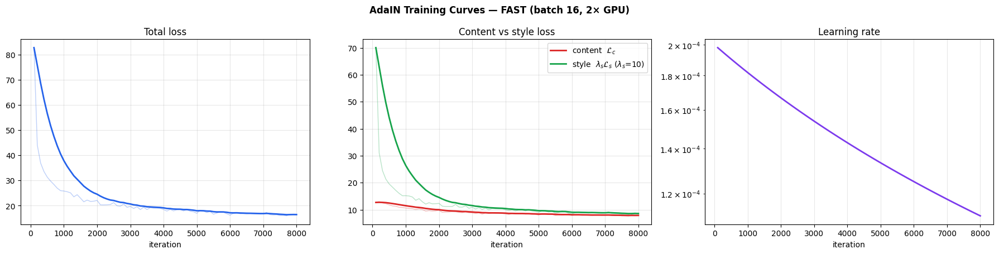

               start       end
total         49.279    16.368
content       12.576     7.853
style          3.670     0.851


In [8]:
# ============================================================================
# 8 — Training curves
# ============================================================================
assert history, "No loss history yet — run the training cell (or resume a checkpoint) first."
H = pd.DataFrame(history)
ema = lambda s, span=10: s.ewm(span=span, adjust=False).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
axes[0].plot(H["iter"], H["loss"], color="#2563eb", alpha=0.3, lw=1)
axes[0].plot(H["iter"], ema(H["loss"]), color="#2563eb", lw=2)
axes[0].set_title("Total loss")

axes[1].plot(H["iter"], H["loss_c"], color="#dc2626", alpha=0.3, lw=1)
axes[1].plot(H["iter"], ema(H["loss_c"]), color="#dc2626", lw=2, label=r"content  $\mathcal{L}_c$")
axes[1].plot(H["iter"], STYLE_WEIGHT * H["loss_s"], color="#16a34a", alpha=0.3, lw=1)
axes[1].plot(H["iter"], ema(STYLE_WEIGHT * H["loss_s"]), color="#16a34a", lw=2,
             label=rf"style  $\lambda_s\mathcal{{L}}_s$ ($\lambda_s$={STYLE_WEIGHT:g})")
axes[1].set_title("Content vs style loss"); axes[1].legend()

axes[2].plot(H["iter"], H["lr"], color="#7c3aed", lw=2)
axes[2].set_yscale("log"); axes[2].set_title("Learning rate")

for ax in axes:
    ax.set_xlabel("iteration"); ax.grid(alpha=0.3)
fig.suptitle(f"AdaIN Training Curves — {CONFIG_NAME} (batch {BATCH_SIZE}, {max(1, N_GPUS)}× GPU)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

first, last = H.iloc[: max(1, len(H) // 20)].mean(), H.iloc[-max(1, len(H) // 20):].mean()
print(f"{'':10s}{'start':>10s}{'end':>10s}")
for k, name in [("loss", "total"), ("loss_c", "content"), ("loss_s", "style")]:
    print(f"{name:10s}{first[k]:10.3f}{last[k]:10.3f}")

#### 📝 Interpretation
- The **style loss drops fastest** (×4.3, from 3.67 to 0.85): matching the mean and variance of VGG features is the easier part of
  the task, and with λs = 10 it dominates the total loss at the start.
- The **content loss decreases more slowly** (12.6 → 7.9): the decoder has to learn to rebuild a sharp image from re-normalised features,
  which needs many more iterations.
- Both curves are still slightly decreasing at iteration 8,000, so a longer run on more data would keep improving the result.

---
## 9 · Qualitative results — 6 × 6 grid

**Goal:** see how one decoder handles many unseen content / style pairs.

Rows are content images from COCO `val2017` and columns are **held-out** WikiArt paintings — neither was used for training — at α = 1.0.
Each image is encoded once and the 36 combinations reuse those features, so only AdaIN and the decoder run per cell.
Set `GRID_CONTENT` / `GRID_STYLE` to lists of your own image paths to change the grid.

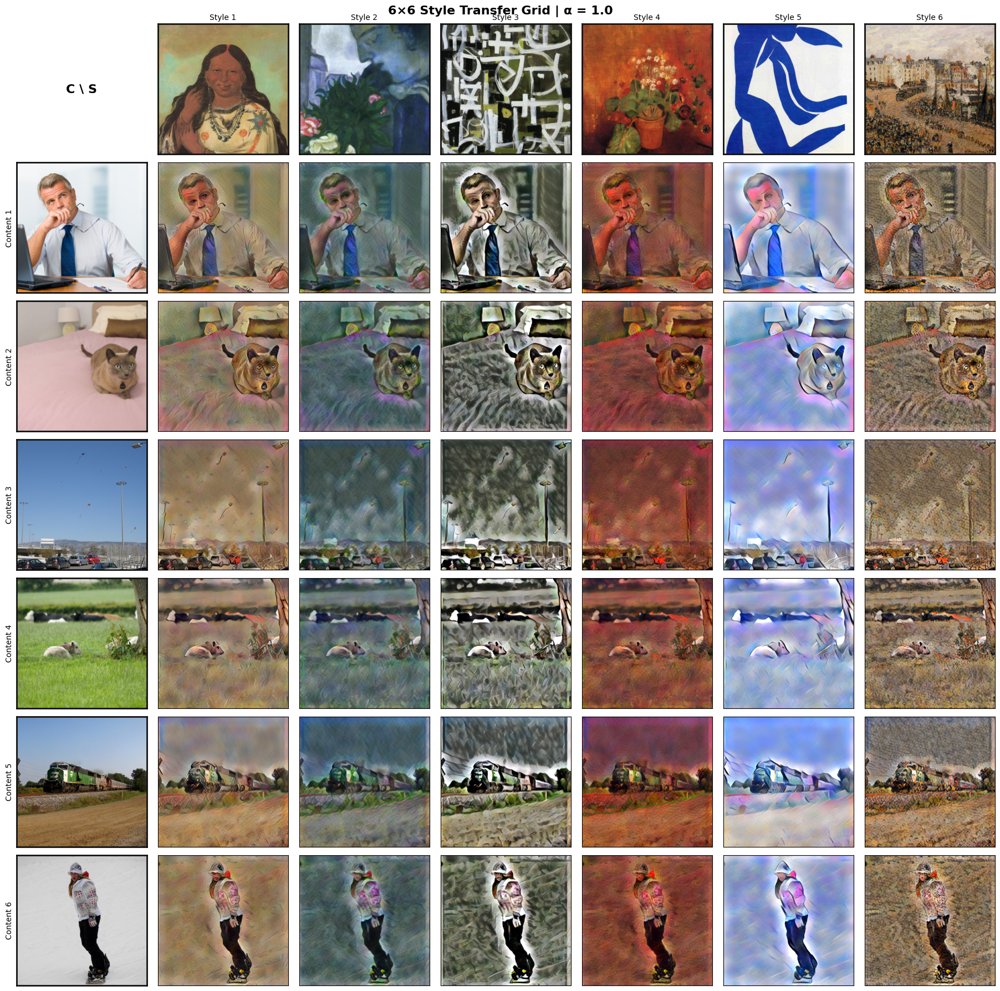

In [9]:
# ============================================================================
# 9 — 6×6 style-transfer grid
# ============================================================================
GRID_N = 6
GRID_SIZE = 512
GRID_CONTENT = None    # optional: list of 6 content image paths
GRID_STYLE = None      # optional: list of 6 style image paths

pick = np.random.default_rng(SEED + 7)
grid_content = GRID_CONTENT or [display_content[i] for i in pick.choice(len(display_content), GRID_N, replace=False)]
grid_style = GRID_STYLE or [heldout_styles[i] for i in pick.choice(len(heldout_styles), GRID_N, replace=False)]

decoder.eval()
c_imgs = [load_image(p, GRID_SIZE, square=True) for p in grid_content]
s_imgs = [load_image(p, GRID_SIZE, square=True) for p in grid_style]
with torch.no_grad():
    c_feats = [encoder.encode(c.unsqueeze(0).to(DEVICE)) for c in c_imgs]
    s_feats = [encoder.encode(s.unsqueeze(0).to(DEVICE)) for s in s_imgs]
    outs = [[decoder(adain(cf, sf)).clamp(0, 1)[0].cpu() for sf in s_feats] for cf in c_feats]

fig, axes = plt.subplots(GRID_N + 1, GRID_N + 1, figsize=(2.6 * (GRID_N + 1), 2.6 * (GRID_N + 1)))
axes[0, 0].axis("off")
axes[0, 0].text(0.5, 0.5, "C \\ S", ha="center", va="center", fontsize=16, fontweight="bold")
for j, s in enumerate(s_imgs):
    show(axes[0, j + 1], s, f"Style {j + 1}")
for i, c in enumerate(c_imgs):
    show(axes[i + 1, 0], c)
    axes[i + 1, 0].set_ylabel(f"Content {i + 1}", fontsize=10)
    for j in range(GRID_N):
        show(axes[i + 1, j + 1], outs[i][j])
for ax in (axes[0, 1:].tolist() + axes[1:, 0].tolist()):
    for spine in ax.spines.values():
        spine.set_edgecolor("#111"); spine.set_linewidth(2)
fig.suptitle(f"{GRID_N}×{GRID_N} Style Transfer Grid | α = 1.0", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "style_grid_6x6.png", dpi=120, bbox_inches="tight")
plt.show()

#### 📝 Interpretation
- A **single decoder** produces all 36 stylisations: each column takes on its painting's palette and texture, while each row's photo
  stays recognisable. This is the key property of AdaIN — **arbitrary style transfer without retraining**.
- High-contrast, textured styles transfer most visibly (style 3 brings its black-and-white strokes; style 6 its warm, grainy brushwork).
- AdaIN transfers feature **statistics**, not shapes: for the Matisse-like cut-out (style 5) the outputs pick up its blue-and-white
  palette but not its large flat forms.
- Large uniform regions (sky, bedspread, snow) receive the most texture, and some subjects get a light halo; fine details such as faces
  are softened — expected with the reduced training budget.

---
## 10 · Style interpolation (α sweep)

**Goal:** control the strength of the style at inference time, without retraining.

$t_\alpha = \alpha\,\text{AdaIN}(x, y) + (1-\alpha)\,x$ — α = 0 decodes the content features unchanged, α = 1 applies the full style.
Each panel is timed on a single GPU (warm-up first, `torch.cuda.synchronize()` around the timed runs).

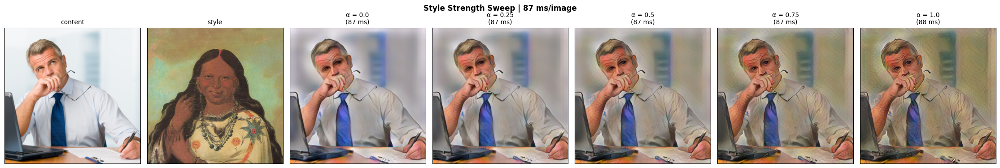

In [10]:
# ============================================================================
# 10 — α sweep with per-image timing
# ============================================================================
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
SWEEP_SIZE = 512

def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

@torch.no_grad()
def timed_stylize(content, style, alpha=1.0, runs=10, warmup=3):
    """Full pipeline (encode content + style, AdaIN, decode) → (image, mean ms per image)."""
    for _ in range(warmup):
        stylize(content, style, alpha)
    sync(); t0 = time.perf_counter()
    for _ in range(runs):
        out = stylize(content, style, alpha)
    sync()
    return out, (time.perf_counter() - t0) / runs * 1e3

decoder.eval()
sweep_c = load_image(grid_content[0], SWEEP_SIZE, square=True)
sweep_s = load_image(grid_style[0], SWEEP_SIZE, square=True)
results = [timed_stylize(sweep_c, sweep_s, a) for a in ALPHAS]
mean_ms = np.mean([ms for _, ms in results])

fig, axes = plt.subplots(1, len(ALPHAS) + 2, figsize=(3.2 * (len(ALPHAS) + 2), 3.9))
show(axes[0], sweep_c, "content")
show(axes[1], sweep_s, "style")
for ax, a, (img, ms) in zip(axes[2:], ALPHAS, results):
    show(ax, img, f"α = {a}\n({ms:.0f} ms)")
fig.suptitle(f"Style Strength Sweep | {mean_ms:.0f} ms/image", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

#### 📝 Interpretation
- The style is blended in **progressively and smoothly**: colours shift first, then texture appears as α grows.
- At α = 0 the output is the decoder's reconstruction of the content features. It keeps the structure but is softer than the input,
  which shows the decoder's reconstruction limit after a short training run.
- Every panel costs the same (≈ 87 ms at 512×512): α only changes a linear blend of feature maps.

---
## 11 · Inference benchmark

**Goal:** measure how "real-time" the model is.

Benchmark on a **single** T4: warm-up passes first, then `torch.cuda.synchronize()` before and after each timed run so the wall-clock
time covers the whole pipeline — encoding content and style, AdaIN, and decoding. Times are given at 512×512 and at 256×256
(the video setting), in fp32 and with fp16 autocast. The table is also saved to `figures/inference_benchmark.csv`.

In [11]:
# ============================================================================
# 11 — Inference benchmark
# ============================================================================
@torch.no_grad()
def benchmark(size, use_fp16=False, runs=50, warmup=5):
    c = torch.rand(1, 3, size, size, device=DEVICE)
    s = torch.rand(1, 3, size, size, device=DEVICE)
    with torch.amp.autocast(device_type="cuda", enabled=use_fp16 and DEVICE.type == "cuda"):
        for _ in range(warmup):
            decoder(adain(encoder.encode(c), encoder.encode(s)))
        times = []
        for _ in range(runs):
            sync(); t0 = time.perf_counter()
            decoder(adain(encoder.encode(c), encoder.encode(s))).clamp(0, 1)
            sync(); times.append((time.perf_counter() - t0) * 1e3)
    return np.mean(times), np.std(times)

decoder.eval()
rows = []
for size in (512, 256):
    for fp16 in (False, True):
        if fp16 and DEVICE.type != "cuda":
            continue
        m, s = benchmark(size, fp16)
        rows.append({"resolution": f"{size}×{size}", "precision": "fp16 (autocast)" if fp16 else "fp32",
                     "ms / image": round(m, 1), "± std": round(s, 1), "images / s": round(1000 / m, 1)})
bench = pd.DataFrame(rows)
gpu_name = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"
print(f"Single-image latency on {gpu_name} (content + style encoding, AdaIN, decoding):\n")
print(bench.to_string(index=False))
bench.to_csv(FIG_DIR / "inference_benchmark.csv", index=False)

Single-image latency on Tesla T4 (content + style encoding, AdaIN, decoding):

resolution       precision  ms / image  ± std  images / s
   512×512            fp32        86.0    0.6        11.6
   512×512 fp16 (autocast)        40.4    0.3        24.8
   256×256            fp32        22.0    0.3        45.4
   256×256 fp16 (autocast)        10.7    0.2        93.3


#### 📝 Interpretation
- **fp16 halves the latency** at both resolutions (86 → 40 ms at 512 px, 22 → 11 ms at 256 px): the T4's tensor cores are only
  used in half precision.
- Cost scales with the number of pixels: 256×256 has 4× fewer pixels than 512×512 and runs ≈ 4× faster.
- At 256 px in fp16 the model processes **≈ 93 images per second**, well above video frame rates.

---
## 12 · Video style transfer

**Goal:** apply the model to a video, frame by frame.

Every frame is treated as an independent content image, stylised with one fixed style and written with OpenCV's `VideoWriter`.
The style statistics are computed **once**, and frames are processed in batches of 8. No temporal-consistency mechanism is applied,
so high-motion clips can flicker.

Point `VIDEO_IN` at your own clip (e.g. a video dataset added as input). If it is `None`, the first video found under `/kaggle/input`
is used; if there is none, a short pan-and-zoom demo clip is generated from a COCO image so the cell always runs.
An H.264 copy is produced with `ffmpeg` so the result plays directly in the notebook.

ℹ no input video found — generated a demo clip from 000000000139.jpg
Stylized 96 frames at 256px (source 24 fps)
  model throughput : 11.5 FPS (encode + AdaIN + decode, batch 8)
  end-to-end       : 10.7 FPS (incl. decoding/encoding video with OpenCV)
  → /kaggle/working/video/demo_input_stylized.mp4


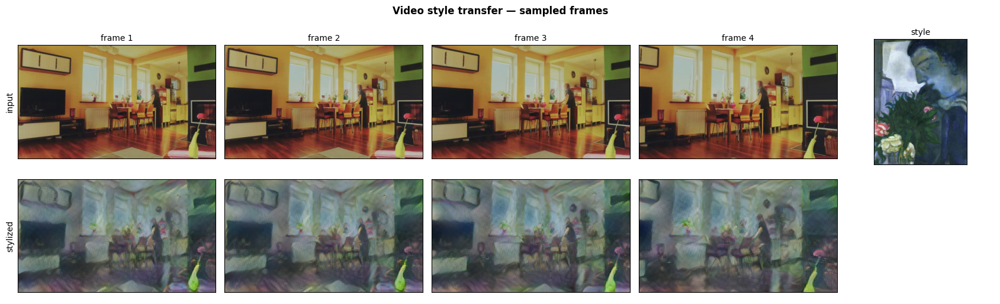

In [12]:
# ============================================================================
# 12 — Video style transfer (frame by frame)
# ============================================================================
import cv2
from IPython.display import Video, display

VIDEO_IN    = None     # path to your clip; None → first video under /kaggle/input, else a generated demo clip
VIDEO_STYLE = None     # path to a style image; None → a held-out WikiArt painting
VIDEO_SIZE  = 256      # shorter side of each frame (256 px keeps video fast)
VIDEO_BATCH = 8
VIDEO_ALPHA = 1.0
MAX_FRAMES  = 240      # ~10 s of video

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

def find_input_video():
    skip = {str(p) for p in (content_dir, style_dir, val_dir) if p}
    for root, dirs, files in os.walk(INPUT):
        if root in skip:
            dirs[:] = []; continue
        dirs[:] = [d for d in dirs if os.path.join(root, d) not in skip]
        for f in sorted(files):
            if os.path.splitext(f)[1].lower() in VIDEO_EXTS:
                return Path(root) / f
    return None

def make_demo_clip(img_path, out_path, seconds=4, fps=24, size=(448, 256)):
    """Slow pan-and-zoom over a still image — a stand-in when no video was provided."""
    img = np.array(TF.resize(load_pil(img_path, 768), 768))
    H, W = img.shape[:2]
    w_out, h_out = size
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w_out, h_out))
    n = seconds * fps
    for k in range(n):
        p = k / (n - 1)
        ch = int(H * (1.0 - 0.3 * p))
        cw = min(W, int(ch * w_out / h_out))
        ch = min(ch, int(cw * h_out / w_out))
        x0 = int((W - cw) * p)
        y0 = (H - ch) // 2
        frame = cv2.resize(img[y0:y0 + ch, x0:x0 + cw], (w_out, h_out), interpolation=cv2.INTER_AREA)
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    writer.release()
    return out_path

@torch.no_grad()
def stylize_video(in_path, style_img, out_path, size=VIDEO_SIZE, batch=VIDEO_BATCH, alpha=VIDEO_ALPHA,
                  max_frames=MAX_FRAMES, n_samples=4):
    cap = cv2.VideoCapture(str(in_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or max_frames
    total = min(total, max_frames)
    sample_at = set(np.linspace(0, total - 1, n_samples).astype(int).tolist())

    s_mean, s_std = calc_mean_std(encoder.encode(style_img.unsqueeze(0).to(DEVICE)))   # style stats once
    writer, buf, idxs = None, [], []
    samples, model_s, n_frames = [], 0.0, 0
    t_start = time.perf_counter()

    def flush():
        nonlocal writer, model_s
        x = torch.stack(buf).to(DEVICE)
        sync(); t0 = time.perf_counter()
        cf = encoder.encode(x)
        t = adain_with_stats(cf, s_mean, s_std)
        y = decoder(alpha * t + (1 - alpha) * cf).clamp(0, 1)
        sync(); model_s += time.perf_counter() - t0
        frames = (y.permute(0, 2, 3, 1).cpu().numpy() * 255).round().astype(np.uint8)
        if writer is None:
            h, w = frames.shape[1:3]
            writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
        for k, fr in zip(idxs, frames):
            writer.write(cv2.cvtColor(fr, cv2.COLOR_RGB2BGR))
            if k in sample_at:
                samples.append((buf[idxs.index(k)].permute(1, 2, 0).numpy(), fr))
        buf.clear(); idxs.clear()

    while n_frames < total:
        ok, frame = cap.read()
        if not ok:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        h, w = rgb.shape[:2]
        scale = size / min(h, w)
        nh, nw = max(8, round(h * scale) // 8 * 8), max(8, round(w * scale) // 8 * 8)
        rgb = cv2.resize(rgb, (nw, nh), interpolation=cv2.INTER_AREA)
        buf.append(torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0)
        idxs.append(n_frames)
        n_frames += 1
        if len(buf) == batch:
            flush()
    if buf:
        flush()
    cap.release()
    if writer is not None:
        writer.release()
    wall = time.perf_counter() - t_start
    return {"frames": n_frames, "fps_in": fps, "model_fps": n_frames / max(model_s, 1e-9),
            "end_to_end_fps": n_frames / wall, "samples": samples}

# ---- pick input clip and style ----
decoder.eval()
video_in = Path(VIDEO_IN) if VIDEO_IN else find_input_video()
if video_in is None:
    video_in = make_demo_clip(display_content[0], VIDEO_DIR / "demo_input.mp4")
    print(f"ℹ no input video found — generated a demo clip from {Path(display_content[0]).name}")
style_path = VIDEO_STYLE or grid_style[min(1, len(grid_style) - 1)]
video_style = load_image(style_path, 512)
video_out = VIDEO_DIR / f"{Path(video_in).stem}_stylized.mp4"

stats = stylize_video(video_in, video_style, video_out)
print(f"Stylized {stats['frames']} frames at {VIDEO_SIZE}px (source {stats['fps_in']:.0f} fps)")
print(f"  model throughput : {stats['model_fps']:.1f} FPS (encode + AdaIN + decode, batch {VIDEO_BATCH})")
print(f"  end-to-end       : {stats['end_to_end_fps']:.1f} FPS (incl. decoding/encoding video with OpenCV)")
print(f"  → {video_out}")

# ---- frame strip: original vs stylized ----
if stats["samples"]:
    n = len(stats["samples"])
    fig, axes = plt.subplots(2, n + 1, figsize=(3.4 * (n + 1), 5.2),
                             gridspec_kw={"width_ratios": [1] * n + [0.75]})
    for j, (orig, sty) in enumerate(stats["samples"]):
        show(axes[0, j], orig, f"frame {j + 1}")
        show(axes[1, j], sty)
    show(axes[0, n], video_style, "style"); axes[1, n].axis("off")
    axes[0, 0].set_ylabel("input"); axes[1, 0].set_ylabel("stylized")
    fig.suptitle("Video style transfer — sampled frames", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "video_frames.png", dpi=120, bbox_inches="tight")
    plt.show()

# ---- browser-playable copy (OpenCV writes MPEG-4 Part 2; notebooks need H.264) ----
h264 = video_out.with_name(video_out.stem + "_h264.mp4")
if shutil.which("ffmpeg"):
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(video_out), "-c:v", "libx264",
                    "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(h264)], check=False)
if h264.exists():
    display(Video(str(h264), embed=True, width=640))
else:
    print("ffmpeg not available — download the .mp4 from /kaggle/working/video/ to watch it.")

#### 📝 Interpretation
- No video was attached, so a 4-second pan-and-zoom clip (96 frames at 24 fps) was generated from a COCO image and stylised with a
  held-out painting.
- Throughput here is ≈ 11 FPS end-to-end in fp32. This includes OpenCV video decoding/encoding and CPU↔GPU copies; with fp16
  (section 11) the model alone runs far above real time at 256 px.
- Because frames are stylised independently, small changes between frames can make textures shimmer — adding a temporal-consistency
  loss or optical-flow warping is the natural next step.

## Outputs
Everything lands in `/kaggle/working/` (kept when you **Save Version**):

| Path | Contents |
|---|---|
| `checkpoints/<run>/ckpt_XXXXXX.pt` | decoder + optimizer + scaler + loss history (last 2 kept locally, all on the Hub) |
| `checkpoints/<run>/decoder_final.pth` | trained decoder weights only (≈14 MB) — all you need for inference with the VGG-19 encoder |
| `checkpoints/<run>/history.json` | loss / learning-rate history |
| `figures/` | training curves, 6×6 grid, α sweep, benchmark table, video frames |
| `previews/` | content \| style \| output strip saved at every checkpoint |
| `video/` | input clip, stylized clip, H.264 copy |